# PCA (Principal Component Analaysis)

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])

In [4]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

X_pca

[0.92461872 0.05306648]


array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [5]:
iris_df['pca_x'] = X_pca[:, 0]
iris_df['pca_y'] = X_pca[:, 1]

iris_df['label'] = iris.target
iris_df.head()


,sepal_length,sepal_width,petal_length,petal_width,pca_x,pca_y,label
0,5.1,3.5,1.4,0.2,-2.684126,0.319397,0
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001,0
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949,0
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299,0
4,5.0,3.6,1.4,0.2,-2.728717,0.326755,0


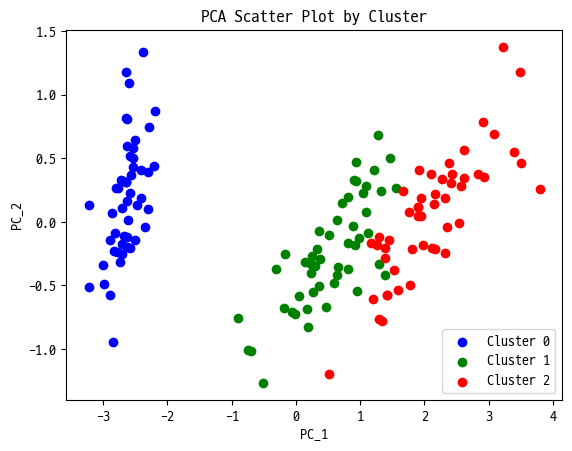

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'D2Coding'   # Linux(나눔폰트 설치 시)
plt.rcParams['axes.unicode_minus'] = False      # - 기호 깨짐 방지

colors = ['blue', 'green', 'red', 'orange']
for label in iris_df['label'].unique() :
    sel_df = iris_df[iris_df['label']==label]
    plt.scatter(sel_df['pca_x'], sel_df['pca_y'], color=colors[label], label=f"Cluster {label}")

plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.title('PCA Scatter Plot by Cluster')
plt.legend()
plt.show()

In [ ]:
pca_df = iris_df[['pca_x', 'pca_y']]
pca_df.head()

,pca_x,pca_y
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


In [9]:
# iris_df 피처를 스케일링
# iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

print("스케일링 후 설명분산비율:", pca_scaled.explained_variance_ratio_)
print("스케일링 후 누적설명분산:", sum(pca_scaled.explained_variance_ratio_))

스케일링 후 설명분산비율: [0.72962445 0.22850762]
스케일링 후 누적설명분산: 0.9581320720000164


2개의 주성분 설명력 확인

- scale 전 : [0.92461872 0.05306648]   
- scale 후 : [0.72962445 0.22850762]

In [14]:
pca_scaled.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

In [11]:
features = ['sepal_length', 'sepal_width', 
            'petal_length', 'petal_width']

loadings_scaled = pd.DataFrame(
    pca_scaled.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("\n=== 스케일링 후 설명분산비율 ===")
print(pca_scaled.explained_variance_ratio_)

print("\n=== 스케일링 후 로딩값 ===")
print(loadings_scaled)


=== 스케일링 후 설명분산비율 ===
[0.72962445 0.22850762]

=== 스케일링 후 로딩값 ===
                   PC1       PC2
sepal_length  0.521066  0.377418
sepal_width  -0.269347  0.923296
petal_length  0.580413  0.024492
petal_width   0.564857  0.066942
